# NCF for movielens

In [1]:
import os, sys

import numpy as np
import pandas as pd
from tqdm import tqdm

import tensorflow as tf

sys.path.insert(0, '..')
from evaluate import ndcg, hr

2023-07-31 14:22:05.914556: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-07-31 14:22:06.100615: E tensorflow/stream_executor/cuda/cuda_blas.cc:2981] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2023-07-31 14:22:06.781190: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; dlerror: libnvinfer.so.7: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /usr/local/cuda/lib64:/usr/local/nccl2/lib:/usr/local/cuda/extras/CUPTI/lib64:/usr/local/cuda/lib64:/usr/local/nccl2/lib:/usr/local/cuda/extras/CUPTI/lib64
2023-07-31 14:22:06.781283: W tensorflow/stream_

# Data Load 

In [2]:
movielens_dir = '../data/ml-1m/'

In [3]:
df = pd.read_csv(os.path.join(movielens_dir, 'ratings.dat'), sep='::', header=None)
df.columns = ['user_id', 'item_id', 'rating', 'timestamp']
print(df.shape)
df.head()

/tmp/ipykernel_10084/1796806906.py:1: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  df = pd.read_csv(os.path.join(movielens_dir, 'ratings.dat'), sep='::', header=None)


(1000209, 4)


,user_id,item_id,rating,timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291


전체 데이터 수 확인, pos, neg 데이터 분배

In [4]:
all_users = list(set(df['user_id']))
all_items = list(set(df['item_id']))

len(all_users), len(all_items), df.shape[0]

(6040, 3706, 1000209)

In [5]:
movie_map = {p:i for i,p in enumerate(all_items)}
user_map = {u:i for i,u in enumerate(all_users)}

len(user_map.keys()), len(movie_map.keys()), df.shape[0]

(6040, 3706, 1000209)

ncf에서 user, item, interaction 수와 정확히 일치하며, README를 통해 20개 이상의 평가를 수행한 유저만 있는 것을 알 수 있음. 위처럼 평가가 있는 모든 데이터를 positive로 함.

# Prepare Train/Test data

- leave-one-out evaluation (positive)
    - 테스트 데이터: 유저의 latest 데이터
    - 학습 데이터: 유저의 나머지 데이터
- 학습 시에는 모든 negative 데이터를 포함
- 평가 시에는 positive test data 하나와 나머지 샘플링한 unobserved 100개 데이터를 합하여 랭킹
- 위 랭킹 결과의 top k에 대해서 positive 가 포함되어 있으면 hit, 그 위치가 어디인지를 NDCG가 측정

In [6]:
# latest 데이터를 test 데이터로 하기 위해 내림차순으로 정렬
df.sort_values(by=['user_id', 'timestamp'], ascending=[True, False], inplace=True)
df.head()

,user_id,item_id,rating,timestamp
25,1,48,5,978824351
32,1,1566,4,978824330
34,1,1907,4,978824330
4,1,2355,5,978824291
30,1,2294,4,978824291


In [7]:
data_pos = [[id_] for id_ in all_users] # user, item, score

for i, row in df.iloc[::-1].iterrows():
    data_pos[user_map[row['user_id']]].append(movie_map[row['item_id']])

In [8]:
train_data = []
test_data = []
avg_pos = 0

for history in tqdm(data_pos):
    avg_pos += len(history)-1
    test_data.append([history[-1]])
    train_data.append(history[1:-1])

print('average history length: ', avg_pos/len(all_users))

100%|██████████| 6040/6040 [00:00<00:00, 323037.84it/s]

average history length:  165.5975165562914


In [9]:
num_negative = 100

In [10]:
def sampling(num_sample, all_items, without):
    idx = 0
    sampled = []
    while idx < num_sample:
        randint = np.random.choice(all_items)
        if movie_map[randint] in without:
            continue
        else:
            # sampled.append([user_map[user_board], pin_map[all_pins[randint]], 0])
            sampled.append(movie_map[randint])
            idx += 1
    return sampled

train_neg, test_neg = [], []

for i, pos in enumerate(train_data):
    train_neg.append(sampling(num_negative, all_items, pos))
    test_neg.append(sampling(100, all_items, pos))

* pinterest -> user: item1, item2, ...
* movielens -> (user, item), (user, item) (user, item)

거꾸로 돌면서 첫번째 등장한 데이터를 테스트 나머지를 트레인으로 두기
양의 데이터는 [user_id, item_id]

In [14]:
train = []

for i, (tp, tn) in enumerate(zip(train_data, train_neg)):
    interactions = len(tp)*[1] + len(tn)*[0]
    train.extend([i, cid, interaction] for cid, interaction in zip(tp+tn, interactions))

In [15]:
test = []

for i, (tp, tn) in enumerate(zip(test_data, test_neg)):
    interactions = [1] + len(tn)*[0]
    test.extend([i, cid, interaction] for cid, interaction in zip(tp+tn, interactions))

In [16]:
train = np.array(train)
test = np.array(test)

In [17]:
len(train)

1598169

In [18]:
np.random.shuffle(train)
np.random.shuffle(test)

# GMF (generalization matrix factorization)

## build

In [19]:
def get_gmf(num_users, num_items, latent_dim):
    
    user_input = tf.keras.layers.Input(shape=1, dtype="float32")
    item_input = tf.keras.layers.Input(shape=1, dtype="float32")

    user_embedding = tf.keras.layers.Embedding(input_dim=num_users, output_dim=latent_dim, name='user_embedding',
                    embeddings_initializer='normal', input_length=1)(user_input)
    item_embedding = tf.keras.layers.Embedding(input_dim=num_items, output_dim=latent_dim, name='item_embedding',
                    embeddings_initializer='normal', input_length=1)(item_input)
    
    user_flatten = tf.keras.layers.Flatten()(user_embedding)
    item_flatten = tf.keras.layers.Flatten()(item_embedding)

    x = tf.keras.layers.Lambda(lambda x: tf.multiply(x[0], x[1]))([user_flatten, item_flatten])
    x = tf.keras.layers.Dense(units=1, activation="sigmoid", dtype="float32", name='last_layer',
        kernel_initializer=tf.keras.initializers.RandomNormal(mean=0.0, stddev=0.01, seed=42))(x)

    model = tf.keras.Model([user_input, item_input], x)
    return model

In [20]:
# hyperparams
learning_rate = 0.001

mirrored_strategy = tf.distribute.MirroredStrategy()

with mirrored_strategy.scope():
  gmf_model = get_gmf(len(all_users), len(all_items), 16)

gmf_model.summary()

2023-07-31 14:38:40.076411: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:980] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2023-07-31 14:38:40.078246: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:980] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2023-07-31 14:38:40.089235: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:980] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2023-07-31 14:38:40.090826: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:980] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2023-07-31 14:38:40.092375: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:980] successful NUMA node read from S

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')
Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 1)]          0           []                               
                                                                                                  
 input_2 (InputLayer)           [(None, 1)]          0           []                               
                                                                                                  
 user_embedding (Embedding)     (None, 1, 16)        96640       ['input_1[0][0]']                
                                                                                                  
 item_embedding (Embedding)     (None, 1, 16

In [21]:
gmf_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate), loss="binary_crossentropy")

INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).


## training

In [22]:
batch_size = 1024 #128, 256, 512
learning_rate = 0.005 #0.0001, 0.0005, 0.005

In [23]:
gmf_history = gmf_model.fit([train[:, 0], train[:, 1]], train[:, 2], epochs=100, 
                            batch_size=batch_size, validation_split=0.1)

Epoch 1/100
INFO:tensorflow:batch_all_reduce: 2 all-reduces with algorithm = nccl, num_packs = 1
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:GPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1').
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:GPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1').
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:batch_all_reduce: 2 all-reduces with algorithm = nccl, num_packs = 1
INFO:tensorflow:Reduce t

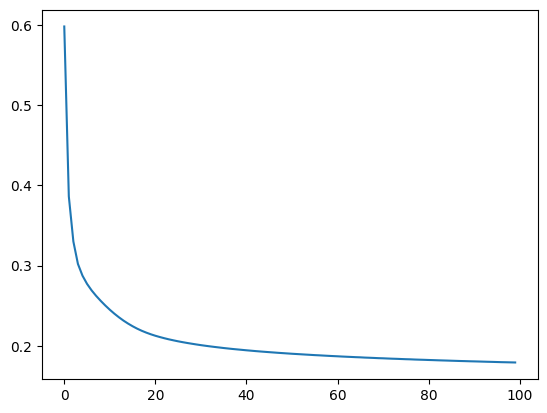

In [24]:
import matplotlib.pyplot as plt

plt.plot(gmf_history.history['loss'])
plt.show()

## prediction

In [25]:
gmf_test_pred = gmf_model.predict([test[:, 0], test[:, 1]], batch_size=2048)

298/298 [==============================] - 2s 3ms/step


## Multi Layer Perceptron

In [43]:
def get_mlp(num_users, num_items, latent_dim, layer_dims):
    
    user_input = tf.keras.layers.Input(shape=1, dtype="float32")
    item_input = tf.keras.layers.Input(shape=1, dtype="float32")

    user_embedding = tf.keras.layers.Embedding(input_dim=num_users, output_dim=latent_dim, name='user_embedding',
                    embeddings_initializer='normal', input_length=1)(user_input)
    item_embedding = tf.keras.layers.Embedding(input_dim=num_items, output_dim=latent_dim, name='item_embedding',
                    embeddings_initializer='normal', input_length=1)(item_input)
    
    user_flatten = tf.keras.layers.Flatten()(user_embedding)
    item_flatten = tf.keras.layers.Flatten()(item_embedding)

    x = tf.keras.layers.Concatenate()([user_flatten, item_flatten])

    # multi layers
    for i, l in enumerate(layer_dims):
        x = tf.keras.layers.Dense(units=l, activation="relu", dtype="float32", name=f'{i}st_layer',
            kernel_initializer=tf.keras.initializers.RandomNormal(mean=0.0, stddev=0.01, seed=42))(x)

    # last layer
    x = tf.keras.layers.Dense(units=1, activation="sigmoid", dtype="float32", name='last_layer',
        kernel_initializer=tf.keras.initializers.RandomNormal(mean=0.0, stddev=0.01, seed=42))(x)

    model = tf.keras.Model([user_input, item_input], x)
    return model

In [56]:
mlp_model = get_mlp(len(all_users), len(all_items), 16, [32, 16, 8])
mlp_model.summary()

Model: "model_6"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_13 (InputLayer)          [(None, 1)]          0           []                               
                                                                                                  
 input_14 (InputLayer)          [(None, 1)]          0           []                               
                                                                                                  
 user_embedding (Embedding)     (None, 1, 16)        96640       ['input_13[0][0]']               
                                                                                                  
 item_embedding (Embedding)     (None, 1, 16)        59296       ['input_14[0][0]']               
                                                                                            

In [57]:
learning_rate = 0.01
mlp_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate), loss="binary_crossentropy")#, metrics=['acc'])

In [58]:
mlp_history = mlp_model.fit([train[:, 0], train[:, 1]], train[:, 2], epochs=100, batch_size=batch_size, validation_split=0.1)

Epoch 1/100
1405/1405 [==============================] - 6s 4ms/step - loss: 0.4125 - val_loss: 0.3841
Epoch 2/100
1405/1405 [==============================] - 5s 4ms/step - loss: 0.3733 - val_loss: 0.3657
Epoch 3/100
1405/1405 [==============================] - 5s 4ms/step - loss: 0.3533 - val_loss: 0.3507
Epoch 4/100
1405/1405 [==============================] - 5s 4ms/step - loss: 0.3378 - val_loss: 0.3399
Epoch 5/100
1405/1405 [==============================] - 5s 4ms/step - loss: 0.3238 - val_loss: 0.3312
Epoch 6/100
1405/1405 [==============================] - 5s 4ms/step - loss: 0.3134 - val_loss: 0.3283
Epoch 7/100
1405/1405 [==============================] - 5s 4ms/step - loss: 0.3044 - val_loss: 0.3256
Epoch 8/100
1405/1405 [==============================] - 5s 4ms/step - loss: 0.2966 - val_loss: 0.3230
Epoch 9/100
1405/1405 [==============================] - 5s 3ms/step - loss: 0.2896 - val_loss: 0.3218
Epoch 10/100
1405/1405 [==============================] - 5s 4ms/step - l

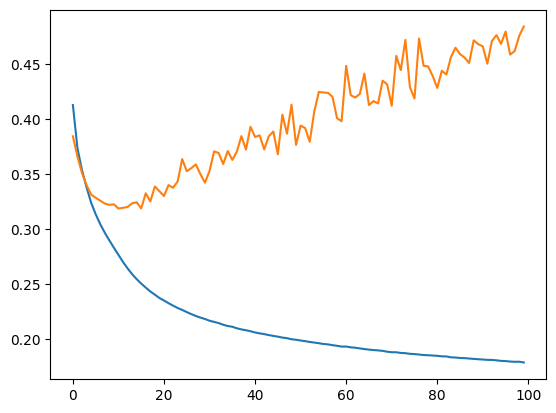

In [59]:
import matplotlib.pyplot as plt

plt.plot(mlp_history.history['loss'])
plt.plot(mlp_history.history['val_loss'])
plt.show()

In [ ]:
mlp_test_pred = mlp_model.predict([test[:, 0], test[:, 1]], batch_size=2048)

298/298 [==============================] - 1s 1ms/step


# NeuMF (Neural Matrix Factorization)

In [27]:
topn = 10

In [28]:
# 
ndcg_values = ndcg.average_ndcg(test[:, 0], gmf_test_pred, test[:, 2], topn, len(all_users))
hr_values, hits = hr.average_hr(test[:, 0], gmf_test_pred, test[:, 2], topn, len(all_users))

ndcg_values, hr_values

(0.2798568482911307, 0.5248344370860927)

In [ ]:
# mlp
ndcg_values = ndcg.average_ndcg(test[:, 0], mlp_test_pred, test[:, 2], topn, len(all_users))
hr_values, hits = hr.average_hr(test[:, 0], mlp_test_pred, test[:, 2], topn, len(all_users))

ndcg_values, hr_values

# Evaluation

In [ ]:
def get_neuMF(num_users, num_items, latent_dim, layer_dims):

    # common inputs
    user_input = tf.keras.layers.Input(shape=1, dtype="float32")
    item_input = tf.keras.layers.Input(shape=1, dtype="float32")

    # gmf branch
    gmf_user_embedding = tf.keras.layers.Embedding(input_dim=num_users, output_dim=latent_dim, name='gmf_user_embedding',
                    embeddings_initializer='normal', input_length=1)(user_input)
    gmf_item_embedding = tf.keras.layers.Embedding(input_dim=num_items, output_dim=latent_dim, name='gmf_item_embedding',
                    embeddings_initializer='normal', input_length=1)(item_input)
    
    gmf_user_flatten = tf.keras.layers.Flatten()(gmf_user_embedding)
    gmf_item_flatten = tf.keras.layers.Flatten()(gmf_item_embedding)

    gmf_multiply = tf.keras.layers.Lambda(lambda x: tf.multiply(x[0], x[1]), name='gmf_multiply')(
        [gmf_user_flatten, gmf_item_flatten])

    # mlp branch
    mlp_user_embedding = tf.keras.layers.Embedding(input_dim=num_users, output_dim=latent_dim, name='mlp_user_embedding',
                    embeddings_initializer='normal', input_length=1)(user_input)
    mlp_item_embedding = tf.keras.layers.Embedding(input_dim=num_items, output_dim=latent_dim, name='mlp_item_embedding',
                    embeddings_initializer='normal', input_length=1)(item_input)
    
    mlp_user_flatten = tf.keras.layers.Flatten()(mlp_user_embedding)
    mlp_item_flatten = tf.keras.layers.Flatten()(mlp_item_embedding)

    x = tf.keras.layers.Concatenate()([mlp_user_flatten, mlp_item_flatten])

    # multi layers
    for i, l in enumerate(layer_dims):
        x = tf.keras.layers.Dense(units=l, activation="relu", dtype="float32", name=f'{i}st_layer',
            kernel_initializer=tf.keras.initializers.RandomNormal(mean=0.0, stddev=0.01, seed=42))(x)
        
    # concat branches
    x = tf.keras.layers.Concatenate()([gmf_multiply, x])

    # last layer
    neumf_last_layer = tf.keras.layers.Dense(units=1, activation="sigmoid", dtype="float32", name='last_layer',
        kernel_initializer=tf.keras.initializers.RandomNormal(mean=0.0, stddev=0.01, seed=42), bias_constraint=None)(x)

    neumf_model = tf.keras.Model([user_input, item_input], neumf_last_layer)
    return neumf_model


In [ ]:
neuMF_model = get_neuMF(len(all_users), len(all_items), 16, [32, 16, 8])
neuMF_model.summary()

## load saved weights

In [ ]:
learning_rate = 0.01
neuMF_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate, validation_split=0.1)

## Training

In [ ]:
neuMF_history = neuMF_model.fit([train[:, 0], train[:, 1]], train[:, 2], epochs=150, batch_size=2048)

In [ ]:
import matplotlib.pyplot as plt

plt.plot(neuMF_history.history['loss'])
plt.show()

In [ ]:
neuMF_test_pred = neuMF_model.predict([test[:, 0], test[:, 1]], batch_size=2048)

In [ ]:
# neuMF
ndcg_values = ndcg.average_ndcg(test[:, 0], neuMF_test_pred, test[:, 2], topn, len(all_users))
hr_values, hits = hr.average_hr(test[:, 0], neuMF_test_pred, test[:, 2], topn, len(all_users))

ndcg_values, hr_values